In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('All imports done.')

All imports done.


In [2]:
# ── CHANGE ONLY THESE 3 VALUES ──────────────────────────────
DB_USER     = 'root'
DB_PASSWORD = '12345'   # <-- your password
DB_NAME     = 'retail_oltp'
# ────────────────────────────────────────────────────────────

DB_HOST = '127.0.0.1'
DB_PORT = 3306

engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    pool_pre_ping=True
)

# Quick test
with engine.connect() as conn:
    print('Connection successful:', DB_NAME)

Connection successful: retail_oltp


In [3]:
def load_table(table_name, limit=None):
    q = f'SELECT * FROM {table_name}'
    if limit:
        q += f' LIMIT {limit}'
    df = pd.read_sql(q, engine)
    print(f'{table_name:30s} → {df.shape[0]:>7,} rows × {df.shape[1]:>2} cols')
    return df

# Load all tables
df_customers        = load_table('customers')
df_products         = load_table('products')
df_stores           = load_table('stores')
df_brands           = load_table('brands')
df_categories       = load_table('categories')
df_suppliers        = load_table('suppliers')
df_orders           = load_table('sales_orders')
df_order_items      = load_table('sales_order_items')
df_inventory        = load_table('inventory')
df_payment_modes    = load_table('lookup_payment_mode')
df_order_status     = load_table('lookup_order_status')

customers                      →  20,000 rows × 17 cols
products                       →   2,000 rows × 13 cols
stores                         →     500 rows × 11 cols
brands                         →     186 rows ×  3 cols
categories                     →     161 rows ×  5 cols
suppliers                      →     300 rows × 12 cols
sales_orders                   →  50,000 rows × 13 cols
sales_order_items              →  50,000 rows ×  8 cols
inventory                      →  48,830 rows ×  7 cols
lookup_payment_mode            →       6 rows ×  2 cols
lookup_order_status            →       5 rows ×  2 cols


### EDA Checklist — Missing Values, Dtypes, Duplicates

In [4]:
def eda_summary(df, name):
    print(f'\n{"="*50}')
    print(f'TABLE: {name}  |  Shape: {df.shape}')
    print(f'{"="*50}')
    
    # Dtypes + Missing
    summary = pd.DataFrame({
        'dtype'       : df.dtypes,
        'null_count'  : df.isnull().sum(),
        'null_pct'    : (df.isnull().sum() / len(df) * 100).round(2),
        'unique'      : df.nunique()
    })
    print(summary[summary['null_count'] > 0].to_string() if summary['null_count'].sum() > 0 
          else '  No missing values.')
    
    # Duplicates
    dups = df.duplicated().sum()
    print(f'  Duplicate rows: {dups}')
    
    return summary

for name, df in [
    ('customers',     df_customers),
    ('products',      df_products),
    ('stores',        df_stores),
    ('sales_orders',  df_orders),
    ('order_items',   df_order_items),
    ('inventory',     df_inventory),
]:
    eda_summary(df, name)


TABLE: customers  |  Shape: (20000, 17)
        dtype  null_count  null_pct  unique
email  object       20000    100.00       0
phone  object       20000    100.00       0
  Duplicate rows: 0

TABLE: products  |  Shape: (2000, 13)
  No missing values.
  Duplicate rows: 0

TABLE: stores  |  Shape: (500, 11)
  No missing values.
  Duplicate rows: 0

TABLE: sales_orders  |  Shape: (50000, 13)
                   dtype  null_count  null_pct  unique
discount_amount  float64          18      0.04    8707
  Duplicate rows: 0

TABLE: order_items  |  Shape: (50000, 8)
                    dtype  null_count  null_pct  unique
discount_percent  float64          15      0.03    3740
discount_amount   float64          18      0.04    8707
  Duplicate rows: 0

TABLE: inventory  |  Shape: (48830, 7)
  No missing values.
  Duplicate rows: 0


In [5]:
print('── CUSTOMERS ──')
display(df_customers[['age_group','avg_monthly_spend_inr','visit_frequency_per_month','city_tier']]
        .describe(include='all'))

print('\n── PRODUCTS ──')
display(df_products[['mrp','cost_price','gross_margin_pct']].describe())

print('\n── ORDERS ──')
display(df_orders[['total_amount','discount_amount','net_amount']].describe())

print('\n── ORDER ITEMS ──')
display(df_order_items[['quantity','unit_price','discount_percent','discount_amount','net_price']].describe())

── CUSTOMERS ──


,age_group,avg_monthly_spend_inr,visit_frequency_per_month,city_tier
count,20000,20000.00,20000.00,20000.00
unique,6,NaN,NaN,NaN
top,26-35,NaN,NaN,NaN
freq,6004,NaN,NaN,NaN
mean,NaN,4609.12,5.86,1.65
std,NaN,2066.95,3.01,0.72
min,NaN,1050.00,1.00,1.00
25%,NaN,2990.00,4.00,1.00
50%,NaN,4440.00,5.00,2.00
75%,NaN,6020.00,8.00,2.00



── PRODUCTS ──


,mrp,cost_price,gross_margin_pct
count,2000.00,2000.00,2000.00
mean,226.45,173.76,23.30
std,255.96,197.17,6.47
min,5.00,4.25,12.02
25%,75.00,56.62,17.64
50%,150.00,113.25,23.20
75%,270.00,207.08,28.78
max,2320.00,1980.86,34.98



── ORDERS ──


,total_amount,discount_amount,net_amount
count,50000.00,49982.00,50000.00
mean,616.24,21.53,616.24
std,835.01,37.58,835.01
min,3.93,0.00,3.93
25%,161.93,3.68,161.93
50%,343.52,9.74,343.52
75%,738.21,23.61,738.21
max,11366.85,893.08,11366.85



── ORDER ITEMS ──


,quantity,unit_price,discount_percent,discount_amount,net_price
count,50000.00,50000.00,49985.00,49982.00,50000.00
mean,2.99,227.07,0.09,21.53,616.24
std,1.41,257.37,0.08,37.58,835.01
min,1.00,5.00,0.00,0.00,3.93
25%,2.00,75.00,0.04,3.68,161.93
50%,3.00,150.00,0.07,9.74,343.52
75%,4.00,270.00,0.13,23.61,738.21
max,5.00,2320.00,0.40,893.08,11366.85


In [6]:
def detect_outliers_iqr(df, col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    mask   = (df[col] < lower) | (df[col] > upper)
    print(f'{col:35s} → outliers: {mask.sum():>5,}  |  range [{lower:.2f}, {upper:.2f}]')
    return df[mask]

print('── ORDER ITEM OUTLIERS ──')
for col in ['quantity','unit_price','net_price','discount_percent']:
    detect_outliers_iqr(df_order_items, col)

print('\n── PRODUCT PRICE OUTLIERS ──')
for col in ['mrp','cost_price','gross_margin_pct']:
    detect_outliers_iqr(df_products, col)

── ORDER ITEM OUTLIERS ──
quantity                            → outliers:     0  |  range [-1.00, 7.00]
unit_price                          → outliers: 3,871  |  range [-217.50, 562.50]
net_price                           → outliers: 3,818  |  range [-702.50, 1602.64]
discount_percent                    → outliers: 2,187  |  range [-0.10, 0.27]

── PRODUCT PRICE OUTLIERS ──
mrp                                 → outliers:   154  |  range [-217.50, 562.50]
cost_price                          → outliers:   156  |  range [-169.07, 432.76]
gross_margin_pct                    → outliers:     0  |  range [0.91, 45.50]


In [7]:
# Orders — parse datetime
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['order_year']  = df_orders['order_date'].dt.year
df_orders['order_month'] = df_orders['order_date'].dt.month
df_orders['order_qtr']   = df_orders['order_date'].dt.quarter
df_orders['order_dow']   = df_orders['order_date'].dt.day_name()

# Products — net margin
df_products['margin_inr'] = df_products['mrp'] - df_products['cost_price']

# Customers — fill nulls
df_customers['avg_monthly_spend_inr'].fillna(0, inplace=True)
df_customers['visit_frequency_per_month'].fillna(1, inplace=True)

print('Cleaning done.')

Cleaning done.


In [8]:
df_orders.head()

,order_id,order_number,customer_id,store_id,order_date,status_id,payment_mode_id,channel_id,total_amount,discount_amount,net_amount,is_return,created_at,order_year,order_month,order_qtr,order_dow
0,1,TXN00000001,8145,324,2024-09-02,3,1,1,853.65,5.45,853.65,0,2026-06-09 13:32:49,2024,9,3,Monday
1,2,TXN00000002,14020,365,2024-06-09,3,1,1,295.74,4.26,295.74,0,2026-06-09 13:32:49,2024,6,2,Sunday
2,3,TXN00000003,14917,46,2025-07-23,3,2,1,324.92,7.77,324.92,0,2026-06-09 13:32:49,2025,7,3,Wednesday
3,4,TXN00000004,10470,233,2025-09-23,3,3,1,341.50,6.70,341.50,0,2026-06-09 13:32:49,2025,9,3,Tuesday
4,5,TXN00000005,3437,9,2025-08-17,3,1,1,411.94,3.03,411.94,0,2026-06-09 13:32:49,2025,8,3,Sunday


In [9]:
# order_items + orders
df_sales = df_order_items.merge(df_orders[['order_id','customer_id','store_id',
                                            'order_date','order_year','order_month',
                                            'order_qtr','order_dow','payment_mode_id']],
                                 on='order_id', how='left')

# + products
df_sales = df_sales.merge(df_products[['product_id','product_name','brand_id',
                                        'category_id','mrp','cost_price','gross_margin_pct']],
                           on='product_id', how='left')

# + brands
df_sales = df_sales.merge(df_brands, on='brand_id', how='left')

# + stores
df_sales = df_sales.merge(df_stores[['store_id','store_name','city','state',
                                      'city_tier','store_type']],
                           on='store_id', how='left')

# + customers
df_sales = df_sales.merge(df_customers[['customer_id','customer_name','gender',
                                         'age_group','loyalty_member','city_tier']],
                           on='customer_id', how='left', suffixes=('_store','_customer'))

# + payment modes
df_sales = df_sales.merge(df_payment_modes, on='payment_mode_id', how='left')

print(f'Master sales df shape: {df_sales.shape}')
df_sales.head(3)

Master sales df shape: (50000, 35)


,order_item_id,order_id,product_id,quantity,unit_price,discount_percent,discount_amount,net_price,customer_id,store_id,order_date,order_year,order_month,order_qtr,order_dow,payment_mode_id,product_name,brand_id,category_id,mrp,cost_price,gross_margin_pct,brand_name,created_at,store_name,city,state,city_tier_store,store_type,customer_name,gender,age_group,loyalty_member,city_tier_customer,payment_mode_name
0,1,799,1,4,224.00,0.18,41.35,730.60,6445,259,2024-11-08,2024,11,4,Friday,5,Pepsodent Toothpaste 200g,1,1,224.00,172.73,22.89,Pepsodent,2026-06-09 13:32:48,SmartShop Hyderabad - Central-99,Hyderabad,Telangana,1,Wholesale,Asha Sharma,F,36-45,0,1,Debit Card
1,2,4544,1,2,224.00,0.12,26.01,395.98,19026,138,2024-06-19,2024,6,2,Wednesday,3,Pepsodent Toothpaste 200g,1,1,224.00,172.73,22.89,Pepsodent,2026-06-09 13:32:48,UrbanMart Guntur - Park-27,Guntur,Andhra Pradesh,3,Department Store,Nikhil Kumar,M,36-45,0,1,Cash
2,3,6408,1,3,224.00,0.03,6.43,652.71,1754,483,2024-07-15,2024,7,3,Monday,3,Pepsodent Toothpaste 200g,1,1,224.00,172.73,22.89,Pepsodent,2026-06-09 13:32:48,SmartShop Vellore - Square-78,Vellore,Tamil Nadu,3,Hypermarket,Lakshmi Banerjee,F,46-55,0,1,Cash


In [10]:
df_sales

,order_item_id,order_id,product_id,quantity,unit_price,discount_percent,discount_amount,net_price,customer_id,store_id,order_date,order_year,order_month,order_qtr,order_dow,payment_mode_id,product_name,brand_id,category_id,mrp,cost_price,gross_margin_pct,brand_name,created_at,store_name,city,state,city_tier_store,store_type,customer_name,gender,age_group,loyalty_member,city_tier_customer,payment_mode_name
0,1,799,1,4,224.00,0.18,41.35,730.60,6445,259,2024-11-08,2024,11,4,Friday,5,Pepsodent Toothpaste 200g,1,1,224.00,172.73,22.89,Pepsodent,2026-06-09 13:32:48,SmartShop Hyderabad - Central-99,Hyderabad,Telangana,1,Wholesale,Asha Sharma,F,36-45,0,1,Debit Card
1,2,4544,1,2,224.00,0.12,26.01,395.98,19026,138,2024-06-19,2024,6,2,Wednesday,3,Pepsodent Toothpaste 200g,1,1,224.00,172.73,22.89,Pepsodent,2026-06-09 13:32:48,UrbanMart Guntur - Park-27,Guntur,Andhra Pradesh,3,Department Store,Nikhil Kumar,M,36-45,0,1,Cash
2,3,6408,1,3,224.00,0.03,6.43,652.71,1754,483,2024-07-15,2024,7,3,Monday,3,Pepsodent Toothpaste 200g,1,1,224.00,172.73,22.89,Pepsodent,2026-06-09 13:32:48,SmartShop Vellore - Square-78,Vellore,Tamil Nadu,3,Hypermarket,Lakshmi Banerjee,F,46-55,0,1,Cash
3,4,12999,1,5,224.00,0.06,13.69,1051.55,7424,445,2025-10-04,2025,10,4,Saturday,2,Pepsodent Toothpaste 200g,1,1,224.00,172.73,22.89,Pepsodent,2026-06-09 13:32:48,DailyNeeds Moradabad - Junction-95,Moradabad,Uttar Pradesh,3,Convenience,Ramesh Dubey,M,46-55,0,1,UPI
4,5,23913,1,1,224.00,0.00,0.90,223.10,14490,284,2025-05-13,2025,5,2,Tuesday,2,Pepsodent Toothpaste 200g,1,1,224.00,172.73,22.89,Pepsodent,2026-06-09 13:32:48,UrbanMart Karimnagar - Park-85,Karimnagar,Telangana,3,Department Store,Anil Sharma,M,46-55,0,2,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,33590,2000,5,169.00,0.06,10.78,791.10,2414,299,2024-10-26,2024,10,4,Saturday,2,Goodknight Mosquito Coil pack of 10,101,6,169.00,129.38,23.44,Goodknight,2026-06-09 13:32:48,ValueStore Srinagar - Main-21,Srinagar,Jammu and Kashmir,2,Convenience,Advik Dubey,M,36-45,0,2,UPI
49996,49997,44073,2000,2,169.00,0.08,13.00,312.00,4185,157,2025-06-15,2025,6,2,Sunday,5,Goodknight Mosquito Coil pack of 10,101,6,169.00,129.38,23.44,Goodknight,2026-06-09 13:32:48,ValueStore Udaipur - Central-63,Udaipur,Rajasthan,3,Express,Varun Chatterjee,M,46-55,0,3,Debit Card
49997,49998,45847,2000,4,169.00,0.02,2.81,664.76,13803,416,2024-03-20,2024,3,1,Wednesday,2,Goodknight Mosquito Coil pack of 10,101,6,169.00,129.38,23.44,Goodknight,2026-06-09 13:32:48,DailyNeeds Tiruchirappalli - East-25,Tiruchirappalli,Tamil Nadu,3,Convenience,Ayaan Reddy,M,36-45,1,2,UPI
49998,49999,47358,2000,5,169.00,0.01,1.59,837.05,13475,376,2024-12-27,2024,12,4,Friday,3,Goodknight Mosquito Coil pack of 10,101,6,169.00,129.38,23.44,Goodknight,2026-06-09 13:32:48,DailyNeeds Salem - Park-53,Salem,Tamil Nadu,3,Hypermarket,Vihaan Das,M,18-25,1,1,Cash


In [11]:
# 8.1 Monthly Revenue
monthly_rev = (df_sales
               .groupby(['order_year','order_month'])
               .agg(total_revenue=('net_price','sum'),
                    total_orders=('order_id','nunique'),
                    avg_order_value=('net_price','mean'))
               .reset_index()
               .sort_values(['order_year','order_month']))

print('── Monthly Revenue (last 6) ──')
display(monthly_rev.tail(6))

── Monthly Revenue (last 6) ──


,order_year,order_month,total_revenue,total_orders,avg_order_value
18,2025,7,1275299.53,2097,608.15
19,2025,8,1379956.88,2128,648.48
20,2025,9,1318710.11,2080,634.00
21,2025,10,1321554.05,2119,623.67
22,2025,11,1139001.85,1993,571.50
23,2025,12,1245132.64,2085,597.19


In [12]:
monthly_rev

,order_year,order_month,total_revenue,total_orders,avg_order_value
0,2024,1,1267045.33,2117,598.51
1,2024,2,1244665.65,1982,627.98
2,2024,3,1329525.95,2112,629.51
3,2024,4,1210552.80,2039,593.70
4,2024,5,1314286.51,2174,604.55
5,2024,6,1307623.92,2037,641.94
6,2024,7,1329190.48,2113,629.05
7,2024,8,1335512.37,2132,626.41
8,2024,9,1207257.97,2032,594.12
9,2024,10,1333215.24,2210,603.26


In [13]:
# 8.2 Revenue by Category
cat_revenue = (df_sales
               .merge(df_categories[['category_id','category_name','level']],
                      on='category_id', how='left')
               .groupby('category_name')
               .agg(revenue=('net_price','sum'),
                    qty=('quantity','sum'),
                    orders=('order_id','nunique'))
               .sort_values('revenue', ascending=False)
               .reset_index())

print('── Top 10 Categories by Revenue ──')
display(cat_revenue.head(10))

── Top 10 Categories by Revenue ──


,category_name,revenue,qty,orders
0,Groceries & Staples,9908464.77,27374,9101
1,Frozen & Non-Veg,4655262.92,16332,5430
2,Home Care,4007821.12,20886,6980
3,Personal Care,3933789.44,18230,6069
4,Beverages,3026576.04,17947,6069
5,Dairy & Bakery,1899375.01,15968,5387
6,Fruits & Vegetables,1759274.83,15036,5000
7,Snacks & Confectionery,1621583.74,17844,5964


In [14]:
cat_revenue

,category_name,revenue,qty,orders
0,Groceries & Staples,9908464.77,27374,9101
1,Frozen & Non-Veg,4655262.92,16332,5430
2,Home Care,4007821.12,20886,6980
3,Personal Care,3933789.44,18230,6069
4,Beverages,3026576.04,17947,6069
5,Dairy & Bakery,1899375.01,15968,5387
6,Fruits & Vegetables,1759274.83,15036,5000
7,Snacks & Confectionery,1621583.74,17844,5964


In [15]:
# 8.3 Store Performance
store_perf = (df_sales
              .groupby(['store_name','city','state','store_type'])
              .agg(revenue=('net_price','sum'),
                   transactions=('order_id','nunique'),
                   avg_basket=('net_price','mean'))
              .sort_values('revenue', ascending=False)
              .reset_index())

print('── Top 10 Stores ──')
display(store_perf.head(10))

── Top 10 Stores ──


,store_name,city,state,store_type,revenue,transactions,avg_basket
0,RetailMart Aligarh - Park-88,Aligarh,Uttar Pradesh,Express,98273.87,113,869.68
1,MegaMart Agra - Park-28,Agra,Uttar Pradesh,Supermarket,95766.81,113,847.49
2,SmartShop Kozhikode - Main-37,Kozhikode,Kerala,Express,94163.41,111,848.32
3,QuickMart Gwalior - Park-32,Gwalior,Madhya Pradesh,Convenience,93421.71,90,1038.02
4,UrbanMart Bhavnagar - Main-03,Bhavnagar,Gujarat,Express,89735.35,124,723.67
5,QuickMart Varanasi - South-05,Varanasi,Uttar Pradesh,Wholesale,89004.84,111,801.85
6,SmartShop Chandigarh - Junction-30,Chandigarh,Chandigarh,Express,88734.80,126,704.24
7,QuickMart Kanpur - Main-01,Kanpur,Uttar Pradesh,Department Store,87449.60,113,773.89
8,FreshKart Asansol - Plaza-92,Asansol,West Bengal,Supermarket,86859.16,122,711.96
9,MegaMart Bareilly - Central-68,Bareilly,Uttar Pradesh,Express,86095.36,108,797.18


In [16]:
# 8.4 pivot_table — Revenue by Store Type × Quarter
pivot_store_qtr = pd.pivot_table(
    df_sales,
    values='net_price',
    index='store_type',
    columns='order_qtr',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
).round(0)

print('── Revenue: Store Type × Quarter ──')
display(pivot_store_qtr)

── Revenue: Store Type × Quarter ──


order_qtr,1,2,3,4,Total
store_type,,,,,
Convenience,1783126.00,1738355.00,1691365.00,1804821.00,7017667.00
Department Store,759797.00,799518.00,832357.00,766648.00,3158319.00
Express,1743722.00,1768588.00,1681181.00,1666603.00,6860094.00
Hypermarket,836267.00,902633.00,966411.00,908860.00,3614170.00
Supermarket,1584686.00,1559162.00,1723181.00,1596724.00,6463753.00
Wholesale,891617.00,923333.00,951432.00,931763.00,3698145.00
Total,7599214.00,7691588.00,7845927.00,7675418.00,30812148.00


In [17]:
# 8.5 pivot_table — Revenue by Gender × Payment Mode
pivot_gender_payment = pd.pivot_table(
    df_sales,
    values='net_price',
    index='gender',
    columns='payment_mode_name',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
).round(0)

print('── Revenue: Gender × Payment Mode ──')
display(pivot_gender_payment)

── Revenue: Gender × Payment Mode ──


payment_mode_name,Cash,Credit Card,Debit Card,Net Banking,UPI,Wallet,Total
gender,,,,,,,
F,3817690.00,2200246.00,1827205.00,767519.00,5265979.00,1194500.00,15073140.00
M,3683131.00,2111596.00,1814500.00,703664.00,5012090.00,1179564.00,14504545.00
O,280564.00,168232.00,144599.00,62666.00,464855.00,113547.00,1234463.00
Total,7781385.00,4480074.00,3786304.00,1533849.00,10742924.00,2487611.00,30812148.00


In [18]:
# 8.6 Customer Segmentation — RFM prep
snapshot_date = df_orders['order_date'].max() + pd.Timedelta(days=1)

rfm = (df_orders
       .groupby('customer_id')
       .agg(
           recency=('order_date',  lambda x: (snapshot_date - x.max()).days),
           frequency=('order_id',  'count'),
           monetary=('net_amount', 'sum')
       )
       .reset_index())

print('── RFM Summary ──')
display(rfm.describe())

── RFM Summary ──


,customer_id,recency,frequency,monetary
count,18371.00,18371.00,18371.00,18371.00
mean,10025.98,227.63,2.72,1677.22
std,5781.46,183.59,1.46,1636.05
min,1.00,1.00,1.00,6.58
25%,5027.50,77.00,2.00,565.11
50%,10025.00,179.00,2.00,1187.92
75%,15051.50,340.00,4.00,2247.26
max,19999.00,730.00,11.00,17953.32


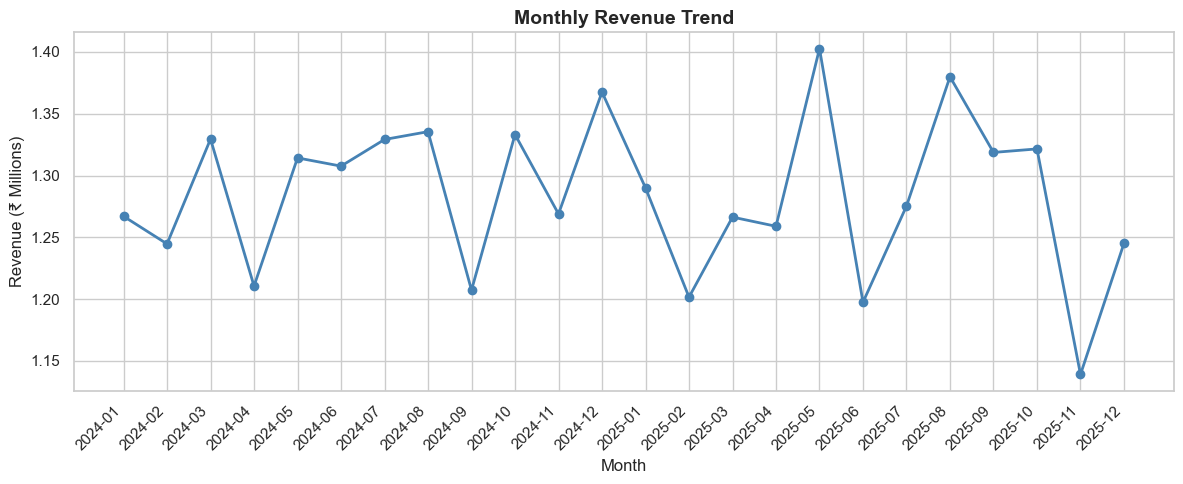

In [19]:
# Chart 1: Monthly Revenue Trend (Line)
fig, ax = plt.subplots()
monthly_rev['period'] = (monthly_rev['order_year'].astype(str) + '-'
                         + monthly_rev['order_month'].astype(str).str.zfill(2))
ax.plot(monthly_rev['period'], monthly_rev['total_revenue'] / 1e6,
        marker='o', linewidth=2, color='steelblue')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹ Millions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

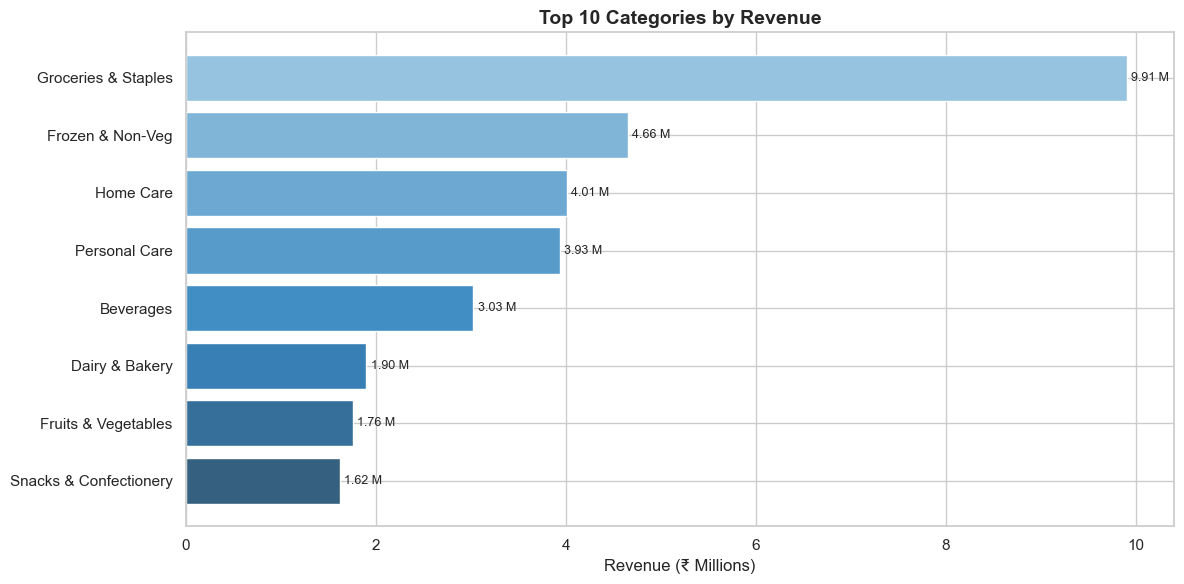

In [25]:
# Chart 2: Top 10 Categories by Revenue (Horizontal Bar)
top10 = cat_revenue.head(10)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['category_name'], top10['revenue'] / 1e6,
               color=sns.color_palette('Blues_d', 10))
ax.set_title('Top 10 Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (₹ Millions)')
ax.bar_label(bars, fmt='%.2f M', padding=3, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

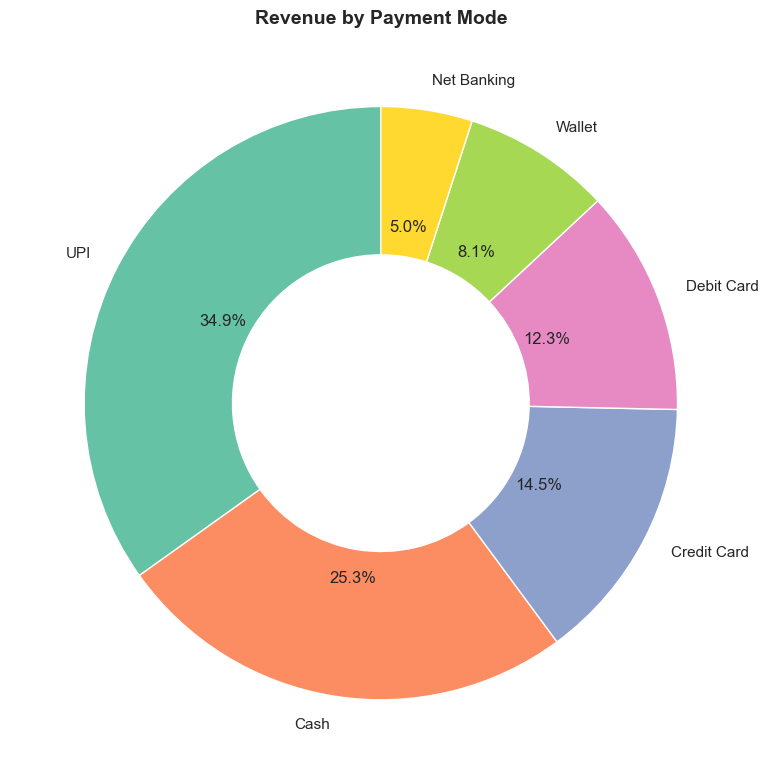

In [21]:
# Chart 3: Payment Mode Distribution (Pie / Donut)
payment_dist = (df_sales
                .groupby('payment_mode_name')['net_price']
                .sum()
                .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    payment_dist,
    labels=payment_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.5},   # donut
    colors=sns.color_palette('Set2', len(payment_dist))
)
ax.set_title('Revenue by Payment Mode', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

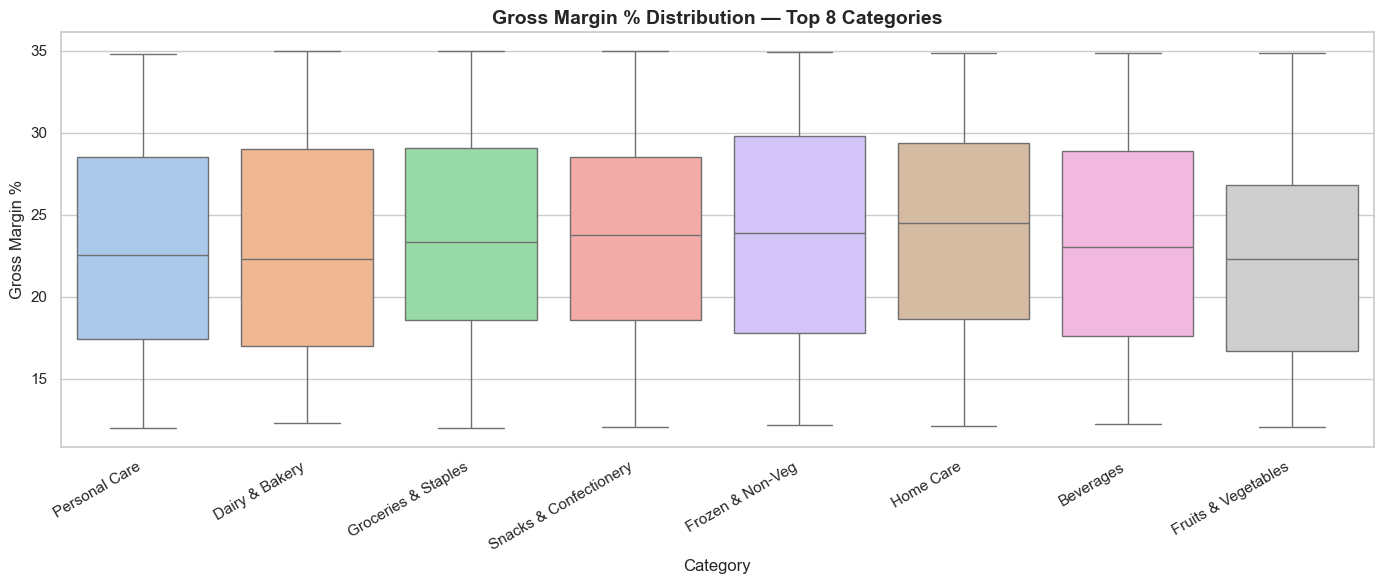

In [22]:
# Chart 4: Gross Margin Distribution by Category (Box Plot)
top8_cats = cat_revenue.head(8)['category_name'].tolist()
df_box = (df_sales
          .merge(df_categories[['category_id','category_name']], on='category_id', how='left')
          .query('category_name in @top8_cats'))

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_box, x='category_name', y='gross_margin_pct',
            palette='pastel', ax=ax)
ax.set_title('Gross Margin % Distribution — Top 8 Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Gross Margin %')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

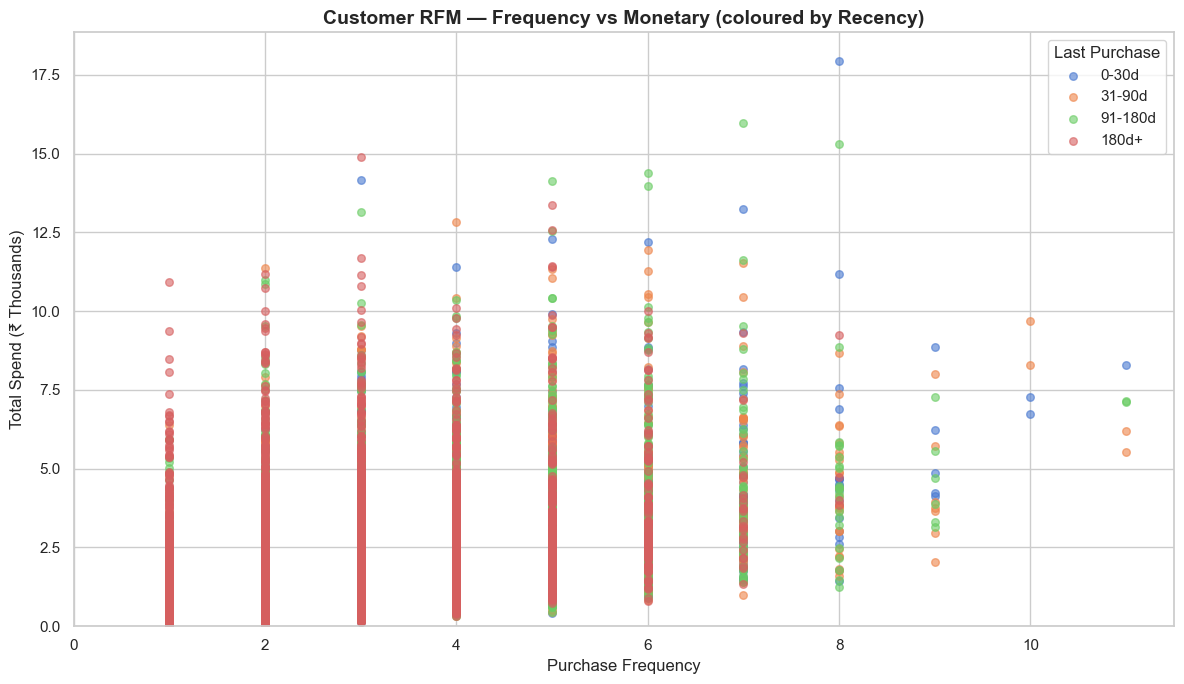

In [23]:
# Chart 5: RFM Scatter — Frequency vs Monetary (coloured by Recency bucket)
rfm['recency_bucket'] = pd.cut(rfm['recency'],
                                bins=[0, 30, 90, 180, 999],
                                labels=['0-30d','31-90d','91-180d','180d+'])

fig, ax = plt.subplots(figsize=(12, 7))
for bucket, grp in rfm.groupby('recency_bucket', observed=True):
    ax.scatter(grp['frequency'], grp['monetary'] / 1000,
               label=bucket, alpha=0.6, s=30)

ax.set_title('Customer RFM — Frequency vs Monetary (coloured by Recency)', fontsize=14, fontweight='bold')
ax.set_xlabel('Purchase Frequency')
ax.set_ylabel('Total Spend (₹ Thousands)')
ax.legend(title='Last Purchase')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

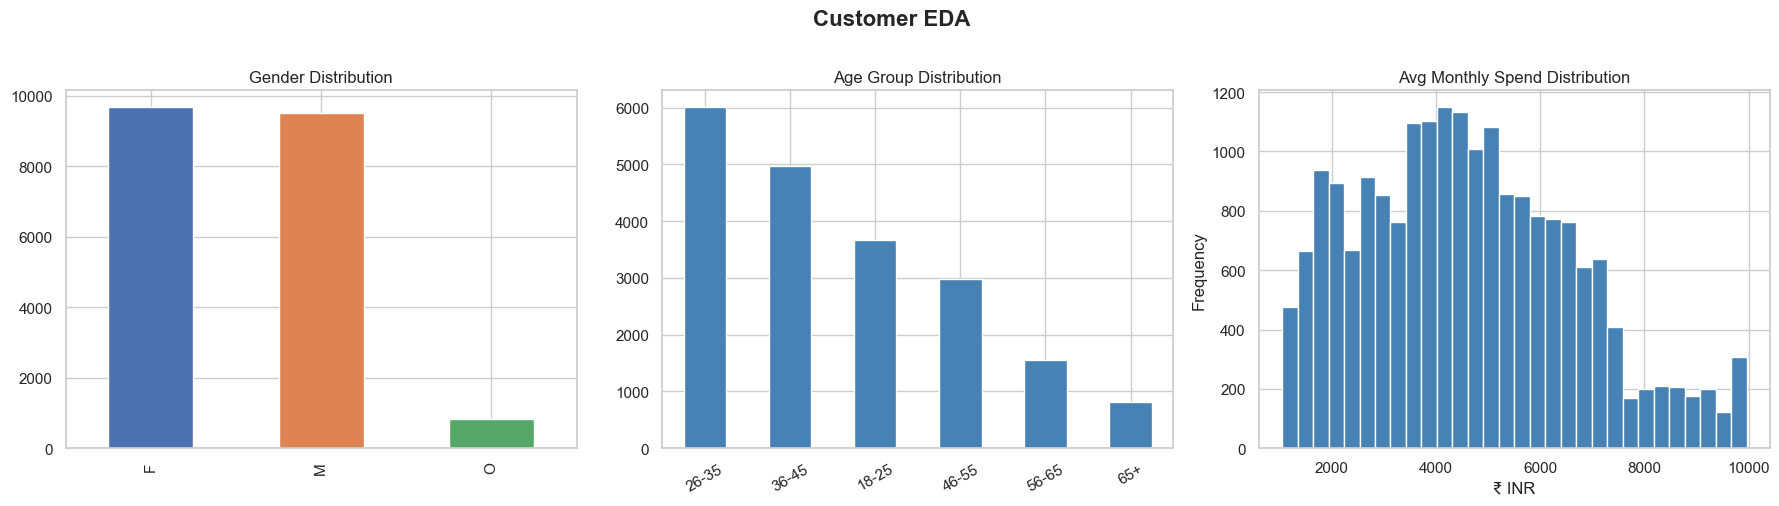

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender split
df_customers['gender'].value_counts().plot.bar(ax=axes[0], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('')

# Age group
df_customers['age_group'].value_counts().plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('Age Group Distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# Avg Monthly Spend histogram
df_customers['avg_monthly_spend_inr'].clip(upper=df_customers['avg_monthly_spend_inr'].quantile(0.99))\
    .plot.hist(bins=30, ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Avg Monthly Spend Distribution')
axes[2].set_xlabel('₹ INR')

plt.suptitle('Customer EDA', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

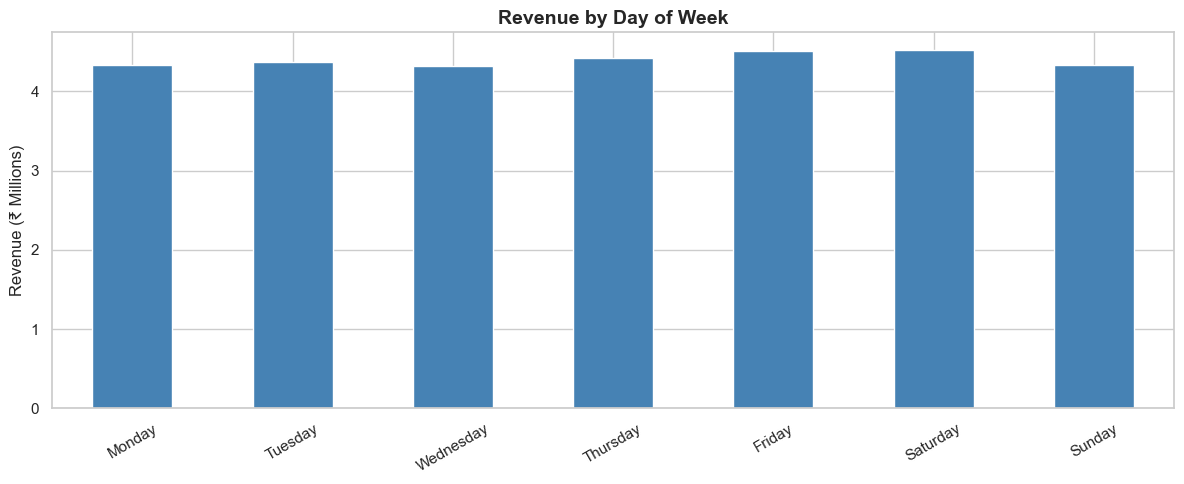

In [26]:
# Day-of-week revenue
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev   = (df_orders
             .groupby('order_dow')['net_amount']
             .sum()
             .reindex(dow_order) / 1e6)

fig, ax = plt.subplots()
dow_rev.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Revenue by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (₹ Millions)')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Orders with discount: 49,978 (100.0%)


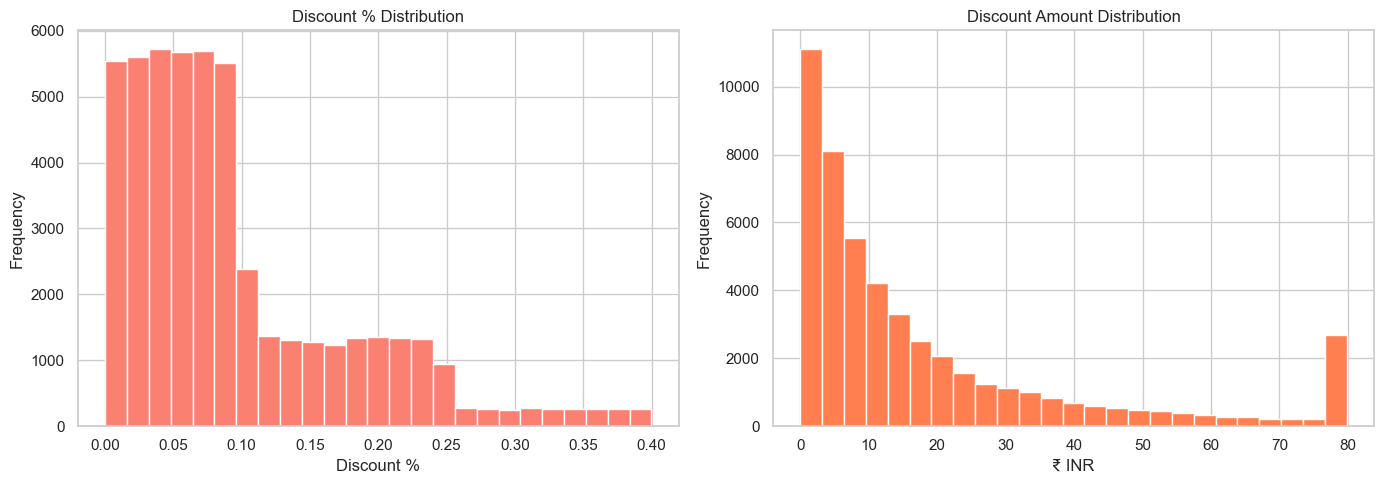

In [27]:
# Discount analysis
disc = df_order_items[df_order_items['discount_percent'] > 0]
print(f'Orders with discount: {len(disc):,} ({len(disc)/len(df_order_items)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disc['discount_percent'].clip(upper=50).plot.hist(
    bins=25, ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('Discount % Distribution')
axes[0].set_xlabel('Discount %')

disc['discount_amount'].clip(upper=disc['discount_amount'].quantile(0.95)).plot.hist(
    bins=25, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Discount Amount Distribution')
axes[1].set_xlabel('₹ INR')

plt.tight_layout()
plt.show()

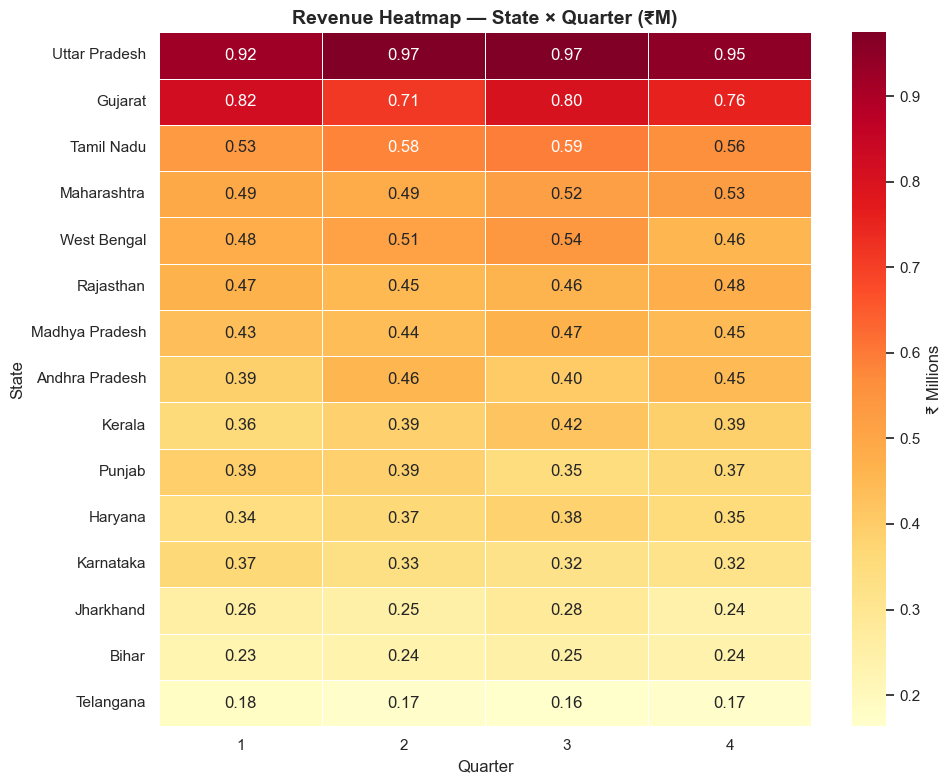

In [29]:
# Heatmap — Revenue by State × Quarter
heatmap_data = pd.pivot_table(
    df_sales,
    values='net_price',
    index='state',
    columns='order_qtr',
    aggfunc='sum',
    fill_value=0
) / 1e6

# Keep top 15 states
top15_states = heatmap_data.sum(axis=1).nlargest(15).index
heatmap_data = heatmap_data.loc[top15_states]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '₹ Millions'})
ax.set_title('Revenue Heatmap — State × Quarter (₹M)', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

In [30]:
# Low stock alert
low_stock = (df_inventory
             .merge(df_products[['product_id','product_name','mrp']], on='product_id')
             .merge(df_stores[['store_id','store_name','city']], on='store_id')
             .query('quantity_on_hand <= reorder_point')
             .sort_values('quantity_on_hand')
             [['store_name','city','product_name','quantity_on_hand','reorder_point','mrp']])

print(f'Low stock SKUs: {len(low_stock):,}')
display(low_stock.head(10))

Low stock SKUs: 235


,store_name,city,product_name,quantity_on_hand,reorder_point,mrp
776,UrbanMart Asansol - Square-12,Asansol,Dhara Sunflower Oil 500ml,0,10,1310.00
1056,CityStore Tiruchirappalli - North-71,Tiruchirappalli,Farm Fresh Cabbage 500g,0,10,50.00
11542,BigBazaar Bareilly - Park-20,Bareilly,Go Cheese Slices 100g,0,10,174.00
7456,BigBazaar Vijayawada - North-84,Vijayawada,Farm Fresh Cabbage 500g,0,10,25.00
9375,QuickMart Durgapur - West-25,Durgapur,Ponds Body Lotion 200ml,0,10,505.00
10663,RetailMart Jodhpur - East-20,Jodhpur,24 Mantra Moong Dal 2kg,0,10,174.00
23813,ValueStore Anand - North-39,Anand,Haldiram's Mixture 200g,0,10,170.00
22188,ValueStore Cuttack - East-42,Cuttack,Happy Hens Country Eggs pack of 10,0,10,99.00
19448,QuickMart Karimnagar - Central-26,Karimnagar,Sting Energy Drink 500ml,0,10,55.00
24719,QuickMart Ranchi - North-34,Ranchi,Amul Butter 500g,0,10,205.00


In [31]:
# Stock coverage by store
stock_summary = (df_inventory
                 .merge(df_stores[['store_id','store_name','city']], on='store_id')
                 .groupby(['store_name','city'])
                 .agg(total_skus=('product_id','count'),
                      zero_stock=('quantity_on_hand', lambda x: (x==0).sum()),
                      total_units=('quantity_on_hand','sum'))
                 .sort_values('total_units', ascending=False))

stock_summary['zero_stock_pct'] = (stock_summary['zero_stock'] / stock_summary['total_skus'] * 100).round(1)
print('── Top 10 Stores by Stock ──')
display(stock_summary.head(10))

── Top 10 Stores by Stock ──


,,total_skus,zero_stock,total_units,zero_stock_pct
store_name,city,,,,
BigBazaar Kozhikode - Plaza-42,Kozhikode,123,0,36822,0.00
ValueStore Tirupati - Park-18,Tirupati,130,0,36243,0.00
DailyNeeds Rohtak - Central-90,Rohtak,123,0,34951,0.00
BigBazaar Jodhpur - Park-99,Jodhpur,120,0,34410,0.00
MegaMart Jabalpur - East-39,Jabalpur,112,0,33794,0.00
SmartShop Junagadh - West-15,Junagadh,117,0,33542,0.00
DailyNeeds Cuttack - West-63,Cuttack,120,0,33450,0.00
UrbanMart Chandigarh - Central-63,Chandigarh,111,0,33236,0.00
DailyNeeds Ajmer - Park-68,Ajmer,116,0,33158,0.00
